In [2]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

dataset = load_dataset("zeroshot/twitter-financial-news-sentiment")

dataset["test"] = dataset.pop("validation")

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

print("Dataset and model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/9543 [00:00<?, ? examples/s]

Map:   0%|          | 0/2388 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Dataset and model loaded successfully!


In [5]:
import numpy as np
import evaluate
from transformers import TrainingArguments, Trainer

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# Fine-Tuning Configurations
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    optim="adamw_torch", # Changed to adamw_torch as adamw_hf is not a valid OptimizerNames
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

print("Starting Fine-Tuning...")
trainer.train()

print("\nPerforming Evaluation...")
eval_results = trainer.evaluate()
print(f"Evaluation Results: {eval_results}")

Starting Fine-Tuning...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.561618,0.378458,0.857621
2,0.332124,0.330486,0.878141
3,0.225834,0.374588,0.882747


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Performing Evaluation...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training Loss,Validation Loss,Epoch,Accuracy
0.225834,0.330486,3,0.878141


Evaluation Results: {'eval_loss': 0.33048614859580994, 'eval_accuracy': 0.878140703517588}


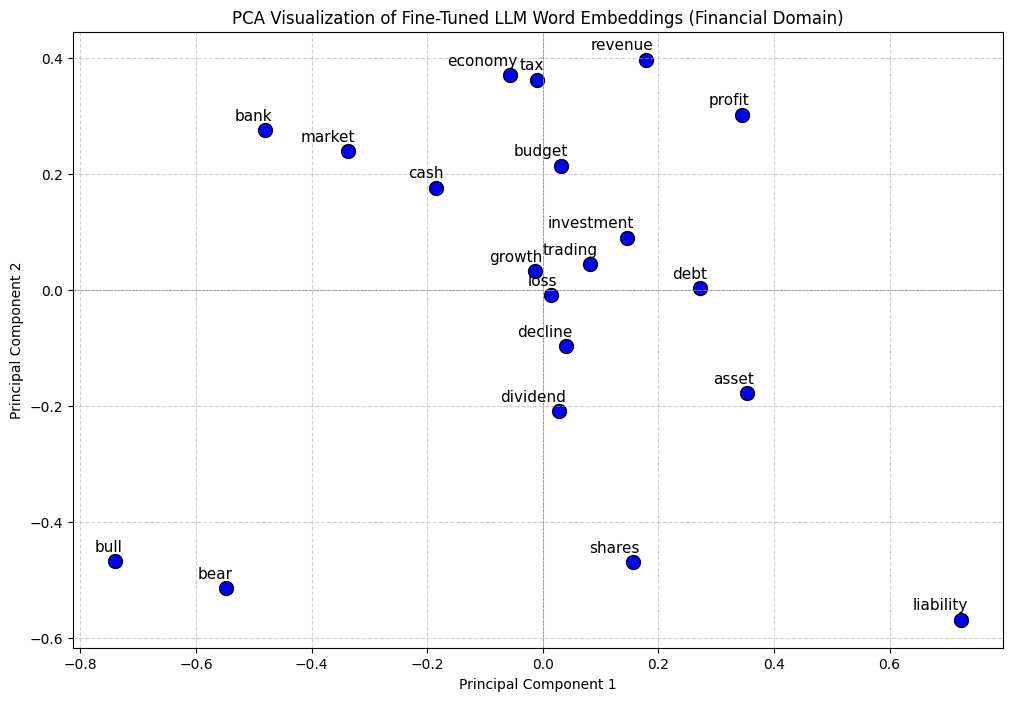

In [7]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 20 known words related to the domain
words = [
    "revenue", "profit", "loss", "debt", "bank", "market", "growth",
    "decline", "dividend", "investment", "bull", "bear", "shares",
    "trading", "economy", "cash", "asset", "liability", "tax", "budget"
]

word_vectors = []
for word in words:
    inputs = tokenizer(word, return_tensors="pt")
    input_ids = inputs["input_ids"][0][1:-1].to(model.device)

    with torch.no_grad():
        embeddings = model.distilbert.embeddings.word_embeddings(input_ids)
        word_vector = embeddings.mean(dim=0).cpu().numpy()
        word_vectors.append(word_vector)

word_vectors = np.array(word_vectors)

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(word_vectors)

plt.figure(figsize=(12, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='blue', edgecolors='k', s=100)

for i, word in enumerate(words):
    plt.annotate(word,
                 (vectors_2d[i, 0], vectors_2d[i, 1]),
                 xytext=(5, 5),
                 textcoords='offset points',
                 ha='right',
                 va='bottom',
                 fontsize=11)

plt.title("PCA Visualization of Fine-Tuned LLM Word Embeddings (Financial Domain)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.axhline(0, color='grey', linestyle='--', linewidth=0.5)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()